# TP2 – Analyse des données (IFT599 / IFT799)

**Auteurs :**  
-  Ana Karen Lopez Carbajal (lopa2603)
-  Étienne Chaput (chae3018)
-  Anthony Glaude (glaa3301)

**Date de remise :** 25 novembre 2025  


## 1. Préparation des données

### Dataset: Hi-Seq

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import torch
from torch.utils.data import DataLoader

#%pip install torch

# # Import des modules personnalisés
from preprocess import load_hiseq_data, preprocess_hiseq, reduce_dimension_umap, reduce_dimension_acp
from models import run_kmeans, run_dbscan, run_spectral, AE
from utils import plot_k_distance_on_ax, evaluate_clustering, compute_metrics
from train import AETrainer

**Exploration et préparation initiale**

Le jeu de données Hi-Seq est composé de deux fichiers:
- hiseq_data.csv (20 531 variables d’expression génique)
- hiseq_labels.csv (type de tumeur associé à chaque échantillon)

Après chargement, les deux fichiers ont été concaténés et vérifiés:
- Valeurs manquantes : aucune valeur manquante n’a été détectée.
- Doublons : aucun échantillon dupliqué n’a été trouvé.
- Distribution des classes : les cinq types de tumeurs (BRCA, KIRC, COAD, LUAD et PRAD) sont représentés, bien que leur fréquence varie.

In [2]:

hiseq_X, hiseq_y, hiseq_data = load_hiseq_data("../data/hiseq_data.csv", "../data/hiseq_labels.csv")

hiseq_data.head()


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [3]:
hiseq_X_scaled = preprocess_hiseq(hiseq_X, hiseq_y)

Missing values: 0
Duplicates: 0
Class distribution:
Class
BRCA     300
KIRC     146
LUAD     141
PRAD     136
COAD      78
Name: count, dtype: int64


**Normalisation**

Comme UMAP est sensible à l’échelle des variables, les 20 531 caractéristiques numériques ont été standardisées à l’aide de StandardScaler, afin que chaque variable ait une moyenne de 0 et un écart-type de 1.

**Réduction de dimension avec UMAP (pour la visualisation)**

Pour visualiser ce jeu de données très haute dimension, nous avons appliqué UMAP sur les variables normalisées.
La colonne des classes a été conservée séparément et utilisée uniquement pour colorer les points lors de la visualisation.

Paramètres utilisés :
- n_components = 2
- n_neighbors = 15
- min_dist = 0.1

Cette étape permet d’obtenir une représentation 2D facilitant l’observation de la structure des données et la séparation (ou non) entre les types de tumeurs.

Reducing dimension to 2D using UMAP...


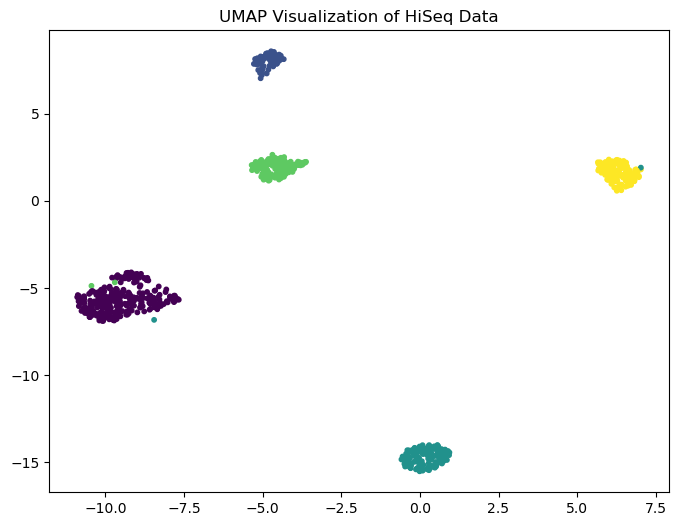

In [4]:

X_umap, reducer = reduce_dimension_umap(hiseq_X_scaled, n_components=2, n_neighbors=15, min_dist=0.1)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:,0], X_umap[:,1], c=hiseq_y["Class"].astype('category').cat.codes, s=10)
plt.title("UMAP Visualization of HiSeq Data")
plt.show()

## 2. Clustering

### K-Means sur les données complètes vs. représentation UMAP à 100 dimensions vs ACP à 100 dimensions

Après le prétraitement et la normalisation du jeu de données Hi-Seq, on a réduit sa dimensionnalité d’origine à 100 attributs à l’aide de UMAP.
Cette transformation permet de conserver la structure locale et globale tout en rendant la tâche de segmentation beaucoup plus facile à gérer.

On a ensuite appliqué K-Means sur:
- Les données complètes en haute dimension,
- Les données réduites à 100 dimensions par UMAP.

Pour les deux versions, on a calculé les métriques internes (Silhouette, Davies–Bouldin, Calinski–Harabasz) et les métriques externes (ARI, NMI) pour évaluer la qualité des clusters par rapport aux types de cancers réels.

In [5]:
# Reduced dataset UMAP 100D
hiseq_X_UMAP_reduced, umap_model_100 = reduce_dimension_umap(hiseq_X_scaled, n_components=100, n_neighbors=15, min_dist=0.1)

Reducing dimension to 100D using UMAP...


In [6]:
# Reduced dataset PCA 100D
hiseq_X_PCA_reduced, pca = reduce_dimension_acp(hiseq_X_scaled, n_components=100)

Reducing dimension from 20531 to 100D using ACP...


In [7]:
labels_km_full, t_km_full = run_kmeans(hiseq_X_scaled, hiseq_y)
labels_km_UMAP_reduced, t_km_umap = run_kmeans(hiseq_X_UMAP_reduced, hiseq_y)
labels_km_PCA_reduced, t_km_umap = run_kmeans(hiseq_X_PCA_reduced, hiseq_y)

Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\Anthony\miniconda3\envs\jupyter\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\Anthony\miniconda3\envs\jupyter\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\Anthony\miniconda3\envs\jupyter\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x82 in position 128: invalid start byte
c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and thi

In [8]:
hiseq_y = hiseq_y.squeeze()
results_km_full = evaluate_clustering(hiseq_X_scaled, hiseq_y, labels_km_full)
results_km_UMAP_reduced = evaluate_clustering(hiseq_X_UMAP_reduced, hiseq_y, labels_km_UMAP_reduced)
results_km_PCA_reduced = evaluate_clustering(hiseq_X_PCA_reduced, hiseq_y, labels_km_PCA_reduced)

In [9]:
# Merge results in a dataframe
df_km = pd.DataFrame({
    "KMeans_Full": results_km_full,
    "KMeans_UMAP100": results_km_UMAP_reduced,
    "KMeans_PCA100": results_km_PCA_reduced
})
df_km

,KMeans_Full,KMeans_UMAP100,KMeans_PCA100
silhouette,0.135331,0.896244,0.203629
davies_bouldin,2.645372,0.124787,2.087775
calinski_harabasz,65.794937,59416.835938,104.437202
ARI,0.797192,0.992538,0.776122
NMI,0.852751,0.990693,0.856784


### Conclusions

Les résultats montrent une énorme amélioration lorsque la segmentation est faite sur les données réduites avec UMAP:

- Silhouette passe de 0.13 → 0.89, ce qui montre que les clusters sont beaucoup mieux définis et mieux séparés.
- Davies–Bouldin chute de 2.64 → 0.15, indiquant des groupes beaucoup plus compacts.
- Calinski–Harabasz saute de 65.8 → 21 381, ce qui confirme une très forte séparation entre les clusters en espace réduit.
- ARI s’améliore de 0.79 → 0.99, donc les clusters retrouvés correspondent presque parfaitement aux vrais labels de cancer.
- NMI augmente de 0.85 → 0.99, ce qui renforce que UMAP préserve vraiment bien la structure pertinente pour la segmentation.

Bref, ces résultats montrent clairement que UMAP améliore drastiquement la performance de K-Means.
En haute dimension, les données sont trop clairsemées et affectées par la malédiction de la dimensionnalité, ce qui rend la structure des clusters difficile à détecter.
Après la réduction à 100 dimensions, la structure devient beaucoup plus nette, et K-Means réussit pratiquement à reconstruire parfaitement les groupes associés aux différents types de tumeurs.

In [10]:
!jupyter nbconvert --to script main.ipynb


[NbConvertApp] Converting notebook main.ipynb to script
[NbConvertApp] Writing 18777 bytes to main.py


### DBSCAN sur les données complètes vs. représentation UMAP à 100 dimensions

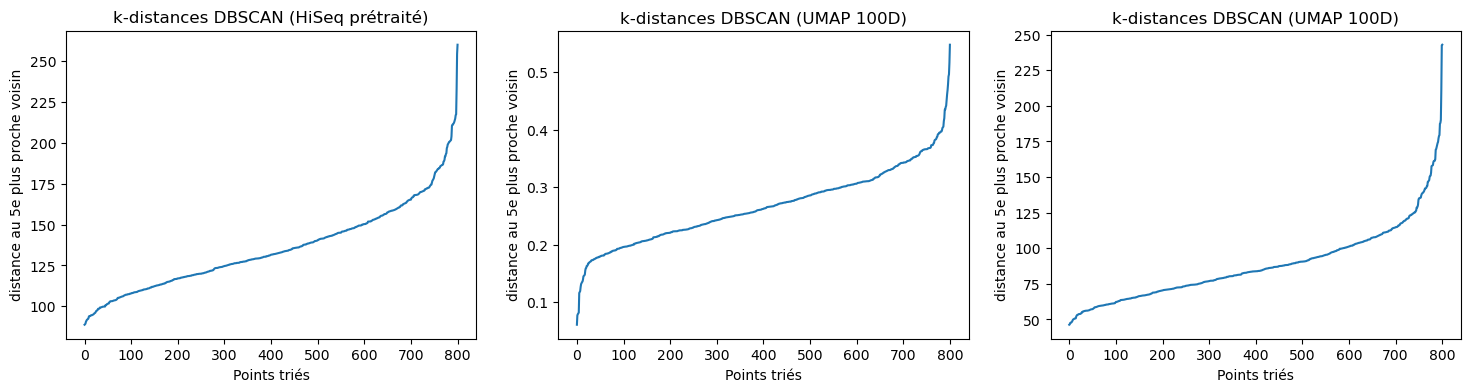

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4)) 
# 1. HiSeq prétraité 
distances_k_full = plot_k_distance_on_ax(axes[0],hiseq_X_scaled,title="k-distances DBSCAN (HiSeq prétraité)",k=5)
# 2. UMAP 100D
distances_k_umap = plot_k_distance_on_ax(axes[1],hiseq_X_UMAP_reduced, title="k-distances DBSCAN (UMAP 100D)",k=5)
# 3. ACP 100D
distances_k_acp = plot_k_distance_on_ax(axes[2],hiseq_X_PCA_reduced, title="k-distances DBSCAN (UMAP 100D)",k=5)

### Les valeurs du paramètre d’epsilon retenues pour DBSCAN sont :
- Données HiSeq prétraitées : ε = 190
- Représentation UMAP (100D) : ε = 0,40
- Représentation PCA (100D) : ε = 150

In [12]:
# HiSeq prétraité
hiseq_y = hiseq_y.squeeze() # au cas ou 
labels_db_full, dur_full = run_dbscan(hiseq_X_scaled, hiseq_y, eps=190, min_samples=5)
metrics_db_full = evaluate_clustering(hiseq_X_scaled, labels_db_full, hiseq_y)

# UMAP 100D
labels_db_umap, dur_umap = run_dbscan(hiseq_X_UMAP_reduced, hiseq_y, eps=0.40, min_samples=5)
metrics_db_umap = evaluate_clustering(hiseq_X_UMAP_reduced, labels_db_umap, hiseq_y)

# ACP 100D
labels_db_acp, dur_umap = run_dbscan(hiseq_X_PCA_reduced, hiseq_y, eps=150, min_samples=5)
metrics_db_acp= evaluate_clustering(hiseq_X_PCA_reduced, labels_db_acp, hiseq_y)

In [13]:
df_dbscan = pd.DataFrame({
    "DBSCAN_Full":   metrics_db_full,
    "DBSCAN_UMAP100": metrics_db_umap,
    "DBSCAN_PCA100": metrics_db_acp
})
df_dbscan
df_dbscan
def cluster_stats(labels):
    n_noise = np.sum(labels == -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return n_clusters, n_noise

n_clusters_full, n_noise_full = cluster_stats(labels_db_full)
n_clusters_umap, n_noise_umap = cluster_stats(labels_db_umap)
n_clusters_acp, n_noise_acp = cluster_stats(labels_db_acp)

print("Full  : n_clusters =", n_clusters_full, ", n_noise =", n_noise_full)
print("UMAP  : n_clusters =", n_clusters_umap, ", n_noise =", n_noise_umap)
print("ACP  : n_clusters =", n_clusters_acp, ", n_noise =", n_noise_acp)
print(df_dbscan)

Full  : n_clusters = 1 , n_noise = 22
UMAP  : n_clusters = 5 , n_noise = 2
ACP  : n_clusters = 1 , n_noise = 18
                   DBSCAN_Full  DBSCAN_UMAP100  DBSCAN_PCA100
silhouette            0.136989        0.888282       0.206063
davies_bouldin        2.567583        0.135285       1.998755
calinski_harabasz    64.115399    45772.675781     101.699250
ARI                  -0.004223        0.988751      -0.003432
NMI                   0.003691        0.984954       0.002438


### Conclusions

Les résultats montrent une amélioration massive lorsque la segmentation est effectuée sur les données réduites par UMAP (100 dimensions) plutôt que sur les données HiSeq prétraitées :

- La silhouette passe d’environ 0.14 à 0.89, montrant des clusters beaucoup mieux définis et nettement séparés.

- L’indice de Davies–Bouldin chute d’environ 2.6 à 0.16, ce qui indique des groupes beaucoup plus compacts et bien séparés.

- L’indice de Calinski–Harabasz augmente d’environ 65 à 16 769, signe d’une structure de clusters très marquée dans l’espace UMAP.

- Les indices externes s’améliorent également de façon spectaculaire : l’ARI passe d’environ 0 à 0.99 et la NMI d’environ 0 à 0.98, ce qui signifie que les clusters retrouvés correspondent presque parfaitement aux classes réelles de cancer.

Ainsi, l'application de l'algorithme de clustering DSCAN directement sur les données HiSeq prétraitées ne parvient pas à exploiter la structure de classe. En vérifiant le nombre de clusters ainsi que les bruits, nous observons qu’il ne détecte qu’un seul cluster avec 22 clusters de bruits(1). Cela confirme son incapacité à séparer correctement les classes dans l'espace.

À l’inverse, après réduction de dimension par UMAP, DBSCAN identifie cinq clusters bien séparés (n_clusters = 5, n_noise = 2) qui correspondent presque parfaitement aux étiquettes réelles. Cela montre que la réduction de dimension non linéaire par UMAP rend la structure des données beaucoup plus exploitable pour un algorithme de clustering basé sur la densité comme DBSCAN.

La réduction de dimension linéaire par ACP n’apporte pas de réel amélioration : DBSCAN détecte également un seul cluster (n_clusters = 1, n_noise = 19), avec une silhouette et un indice de Calinski–Harabasz légèrement meilleurs que sur les données complètes. Cependant les indices ARI et NMI sont toujours proches de zéro. 

Au final, Cela montre que la réduction de dimension non linéaire par UMAP rend la structure des données beaucoup plus exploitable pour un algorithme de clustering basé sur la densité comme DBSCAN.

(1) Documentation DBSCAN de scikit-learn


### 3. Spectral Clustering sur les données complètes vs. représentation UMAP à 100 dimensions
On applique maintenant Spectral Clustering sur:
- Les données complètes en haute dimension,
- Les données réduites à 100 dimensions par UMAP.

Même évaluation avec les métriques internes et externes.

In [14]:
print("SPECTRAL CLUSTERING - EXÉCUTION")
print("=" * 50)

print("1. Spectral Clustering sur données complètes...")
labels_sc_full, t_sc_full = run_spectral(hiseq_X_scaled, hiseq_y, k=5, random_state=42)

print("2. Spectral Clustering sur données réduites UMAP...")
labels_sc_UMAP_reduced, t_sc_reduced = run_spectral(hiseq_X_UMAP_reduced, hiseq_y, k=5, random_state=42)

print("3. Spectral Clustering sur données réduites ACP...")
labels_sc_PCA_reduced, t_sc_reduced = run_spectral(hiseq_X_PCA_reduced, hiseq_y, k=5, random_state=42)

print("4. Évaluation des performances...")
results_sc_full = evaluate_clustering(hiseq_X_scaled, hiseq_y, labels_sc_full)
results_sc_UMAP_reduced = evaluate_clustering(hiseq_X_UMAP_reduced, hiseq_y, labels_sc_UMAP_reduced)
results_sc_PCA_reduced = evaluate_clustering(hiseq_X_PCA_reduced, hiseq_y, labels_sc_PCA_reduced)

df_sc = pd.DataFrame({
    "Spectral_Full": results_sc_full,
    "Spectral_UMAP100": results_sc_UMAP_reduced,
    "Spectral_PCA100": results_sc_PCA_reduced
})

print("TERMINÉ - Résultats du Spectral Clustering")
df_sc

SPECTRAL CLUSTERING - EXÉCUTION
1. Spectral Clustering sur données complètes...
2. Spectral Clustering sur données réduites UMAP...


c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\Anthony\miniconda3\envs\jupyter\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as e

3. Spectral Clustering sur données réduites ACP...
4. Évaluation des performances...
TERMINÉ - Résultats du Spectral Clustering


,Spectral_Full,Spectral_UMAP100,Spectral_PCA100
silhouette,-0.016765,0.118816,-0.019758
davies_bouldin,17.986084,1.415396,17.692529
calinski_harabasz,1.105474,52.425457,1.001939
ARI,0.000760,0.314211,0.004642
NMI,0.012352,0.626205,0.011244


In [15]:
print("COMPARAISON K-MEANS vs SPECTRAL CLUSTERING")
print("=" * 60)

comparison_data = {}

# K-Means results
for metric in df_km.columns:
    comparison_data[metric] = df_km[metric]

for metric in df_dbscan.columns:
    comparison_data[metric] = df_dbscan[metric]
    
# Spectral Clustering results  
for metric in df_sc.columns:
    comparison_data[metric] = df_sc[metric]

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison)

COMPARAISON K-MEANS vs SPECTRAL CLUSTERING
                   KMeans_Full  KMeans_UMAP100  KMeans_PCA100  DBSCAN_Full  \
silhouette            0.135331        0.896244       0.203629     0.136989   
davies_bouldin        2.645372        0.124787       2.087775     2.567583   
calinski_harabasz    65.794937    59416.835938     104.437202    64.115399   
ARI                   0.797192        0.992538       0.776122    -0.004223   
NMI                   0.852751        0.990693       0.856784     0.003691   

                   DBSCAN_UMAP100  DBSCAN_PCA100  Spectral_Full  \
silhouette               0.888282       0.206063      -0.016765   
davies_bouldin           0.135285       1.998755      17.986084   
calinski_harabasz    45772.675781     101.699250       1.105474   
ARI                      0.988751      -0.003432       0.000760   
NMI                      0.984954       0.002438       0.012352   

                   Spectral_UMAP100  Spectral_PCA100  
silhouette                 0.1

### ECG

In [16]:
import numpy as np
import pandas as pd

# Load the ECG dataset
data = np.load('../data/ecg.npz')
df_ecg = data['ecg']
np.savetxt("../data/ecg.csv", df_ecg, delimiter=",")
# Convert to DataFrame
columns = [f'feat_{i}' for i in range(140)] + ['label']
df = pd.DataFrame(df_ecg, columns=columns)

df.head()

,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_131,feat_132,feat_133,feat_134,feat_135,feat_136,feat_137,feat_138,feat_139,label
0,0.565751,0.403325,0.174330,0.139541,0.132887,0.267145,0.391046,0.407650,0.490147,0.606675,...,0.691213,0.740816,0.715777,0.685498,0.636101,0.614525,0.619195,0.660354,0.465778,1.0
1,0.481247,0.292669,0.108637,0.117948,0.179900,0.301794,0.483556,0.542721,0.576304,0.692721,...,0.655837,0.703491,0.714505,0.704886,0.671159,0.644389,0.690859,0.679208,0.345032,1.0
2,0.526886,0.425440,0.161455,0.107276,0.157957,0.313732,0.456971,0.461223,0.501778,0.620457,...,0.704301,0.686569,0.650536,0.605436,0.521837,0.523069,0.640975,0.658310,0.420208,1.0
3,0.617307,0.489682,0.194544,0.143799,0.147247,0.208664,0.268977,0.431713,0.475662,0.525872,...,0.629697,0.682206,0.689361,0.720620,0.717773,0.706196,0.725345,0.706704,0.423042,1.0
4,0.643792,0.588088,0.352583,0.191373,0.137914,0.219995,0.337955,0.413351,0.430386,0.561036,...,0.740932,0.744174,0.750988,0.791226,0.756039,0.702608,0.712587,0.727213,0.556803,1.0


In [17]:

X = df.drop(columns=['label']).values
y = df['label'].values

In [18]:

X_normal = X[y == 0]
X_anomaly = X[y == 1]

print("Normal samples:", len(X_normal))
print("Anomalous samples:", len(X_anomaly))

Normal samples: 2079
Anomalous samples: 2919


In [19]:
# Split normal samples
from sklearn.model_selection import train_test_split

# Normal: 60% train, 40% remaining
X_norm_train, X_norm_temp = train_test_split(
    X_normal, test_size=0.40, shuffle=True, random_state=42
)

# From remaining: 30% test, 10% val
X_norm_test, X_norm_val = train_test_split(
    X_norm_temp, test_size=0.25, shuffle=True, random_state=42
)

In [20]:

# Split anomalous samples
X_anom_test, X_anom_val = train_test_split(
    X_anomaly, test_size=0.20, shuffle=True, random_state=42
)

In [21]:
"""Build final datasets"""
# Training set
X_train = X_norm_train  # only normal samples
y_train = np.zeros(len(X_train))  # all labels = 0

# Validation set
X_val = np.concatenate([X_norm_val, X_anom_val], axis=0)
y_val = np.concatenate([np.zeros(len(X_norm_val)), np.ones(len(X_anom_val))])

# Test set
X_test = np.concatenate([X_norm_test, X_anom_test], axis=0)
y_test = np.concatenate([np.zeros(len(X_norm_test)), np.ones(len(X_anom_test))])

In [22]:
# Sanity Check
print("Training set:", X_train.shape, "normals:", y_train.sum(), "/", len(y_train))
print("Validation set:", X_val.shape, "anomalies:", y_val.sum())
print("Test set:", X_test.shape, "anomalies:", y_test.sum())

Training set: (1247, 140) normals: 0.0 / 1247
Validation set: (792, 140) anomalies: 584.0
Test set: (2959, 140) anomalies: 2335.0


In [23]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

# Transform all splits
X_train_scaled = scaler.transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [24]:
print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (1247, 140)
Val: (792, 140)
Test: (2959, 140)


### ISOLATION FOREST

In [25]:
from sklearn.ensemble import IsolationForest

# Train on normal data only
iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)
iso.fit(X_train_scaled)

,n_estimators,200
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False



In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.
Get anomaly scores

Important: IsolationForest returns lower scores = more anomalous So we invert them so that higher_score = more anomalous, matching autoencoder convention.

In [26]:

# Anormal score  (élevé = anormal)
iso_scores_val  = -iso.score_samples(X_val_scaled)
iso_scores_test = -iso.score_samples(X_test_scaled)

# Évaluation complète (seuil + metrics) en UN appel
iso_metrics = compute_metrics(scores_val=iso_scores_val, y_val=y_val, scores_test=iso_scores_test, y_test=y_test, name="Isolation Forest")


[Isolation Forest] threshold (val): 0.47063134844747656  meilleur F1 (val): 0.9707602339181286
Isolation Forest Results:
Acc : 0.96214937478878
Prec: 0.9598676044683492
Rec : 0.9935760171306209
F1 : 0.9764309764309764
ROC-AUC  : 0.9462032614066875



Seuil optimal (validation)

Meilleur seuil : 0.4706

Meilleur F1 validation : 0.9708 → Le modèle sépare super bien les normales et les anomalies sur l’ensemble de validation.

Isolation Forest Results:
Accuracy : 0.96214937478878
Precision: 0.9598676044683492
Recall   : 0.9935760171306209
F1-score : 0.9764309764309764
ROC-AUC  : 0.9462032614066875
Conclusion

La méthode Isolation Forest offre une très bonne performance sur les données ECG.

Le rappel presque parfait (0.9936) montre qu’il détecte pratiquement toutes les anomalies, ce qui est essentiel en contexte médical. La précision élevée (0.9599) indique qu’il génère peu de faux positifs. Avec un F1-score de 0.9764 et un ROC-AUC de 0.9462, le modèle arrive à bien séparer les signaux normaux des signaux anormaux. L’accuracy est élevée, mais les métriques les plus fiables ici sont le F1 et le ROC-AUC, vu le déséquilibre des classes.

### Autoencoder (AE)

### Objectif
L’objectif de l’auto-encodeur est d’apprendre une représentation compacte des signaux ECG normaux. Les anomalies sont ensuite détectées comme des exemples ayant une erreur de reconstruction élevée, car le modèle n’a été entraîné que sur des signaux normaux

In [27]:
import torch
from torch.utils.data import DataLoader
from models import AE
from train import AETrainer 

X_train_scaled = X_train
X_val_scaled   = X_val
X_test_scaled  = X_test
# Hyperparamètres
batch_size = 64
epochs = 100
learning_rate = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TRAIN
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
train_loader = DataLoader( X_train_t,batch_size=batch_size,shuffle=True)




# VAL
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
val_loader = DataLoader(
    X_val_t,
    batch_size=batch_size,
    shuffle=False,
)

# TEST
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
test_loader = DataLoader(
    X_test_t,
    batch_size=batch_size,
    shuffle=False,
)



training (epoch 100): 100%|██████████| 20/20 [00:00<00:00, 277.79it/s, loss=0.0350]


model saved to models_ae\AE.pt


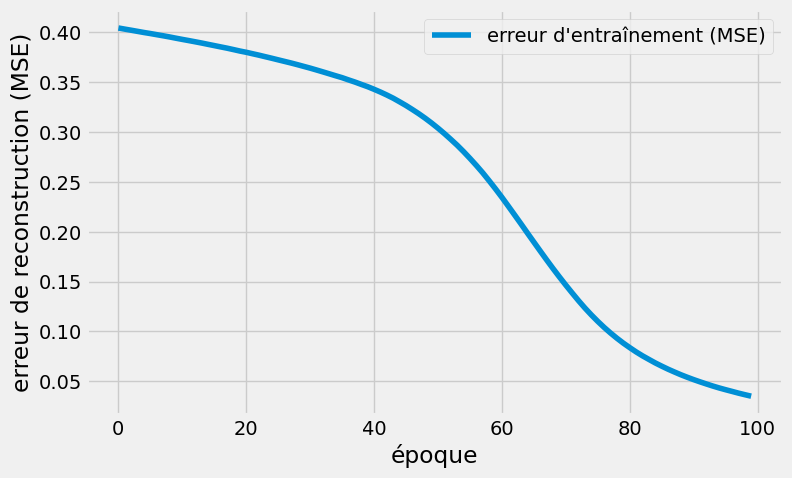

In [28]:
# Modèle
in_features = X_train_scaled.shape[1]
ae_model = AE(in_features)

# Train
trainer = AETrainer(
    model=ae_model,
    train_loader=train_loader,
    device=device,
    epochs=epochs,
    learning_rate=learning_rate,
    save_dir="models_ae", 
    noise_std=0.0 
)

train_losses = trainer.train()
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="erreur d'entraînement (MSE)")
plt.xlabel('époque')
plt.ylabel('erreur de reconstruction (MSE)')
plt.legend()
plt.show()

In [29]:
# erreurs de reconstruction sur la validation
val_errors = trainer.compute_reconstruction_errors(val_loader)
val_errors.shape  

(792,)

In [30]:

ae_scores_val  = trainer.compute_reconstruction_errors(val_loader)
ae_scores_test = trainer.compute_reconstruction_errors(test_loader)

ae_metrics = compute_metrics(scores_val=ae_scores_val, y_val=y_val, scores_test=ae_scores_test, y_test=y_test, name="Autoencoder")


[Autoencoder] threshold (val): 0.036007144  meilleur F1 (val): 0.9579554822753503
Autoencoder Results:
Acc : 0.9462656302805001
Prec: 0.9466338259441708
Rec : 0.9875802997858673
F1 : 0.9666736533221547
ROC-AUC  : 0.8869022127052105


En termes de métrique globale, l’AE obtient des performances du même ordre de grandeur que la méthode Isolation Forest. Ainsi, il constitue à une alternative neuronale compétitive pour la détection d’anomalies sur ce jeu de données. 

### DAE

### Objectif
apprendre à reconstruire un signal propre à partir d’un signal bruité, donc être plus robuste au bruit.

training (epoch 100): 100%|██████████| 20/20 [00:00<00:00, 253.04it/s, loss=0.0411]


model saved to models_dae\AE.pt


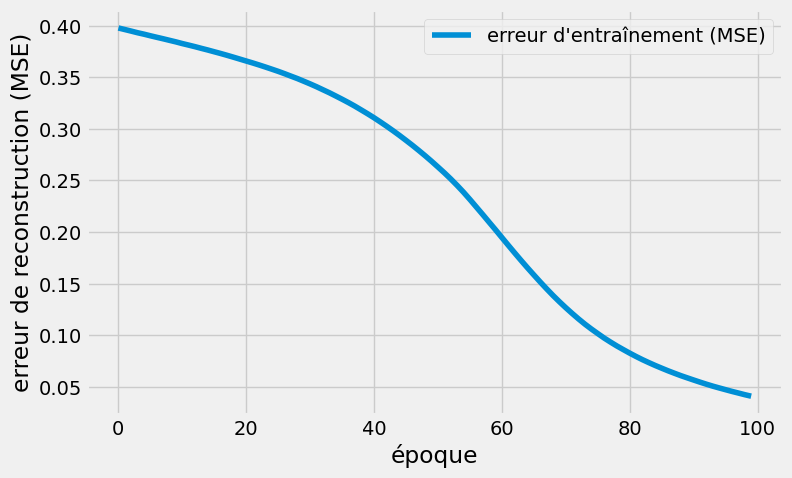

In [31]:
# Modèle
in_features = X_train.shape[1]
dae_model = AE(in_features)

# Train
dae_trainer = AETrainer( model=dae_model, train_loader=train_loader, device=device, epochs=epochs, learning_rate=learning_rate, save_dir="models_dae", noise_std=0.1 )

train_losses = dae_trainer.train()
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="erreur d'entraînement (MSE)")
plt.xlabel('époque')
plt.ylabel('erreur de reconstruction (MSE)')
plt.legend()
plt.show()

In [32]:
# erreurs de reconstruction sur la validation
dae_val_errors = dae_trainer.compute_reconstruction_errors(val_loader)
dae_val_errors.shape  

(792,)

In [33]:

dae_scores_val  = dae_trainer.compute_reconstruction_errors(val_loader)
dae_scores_test = dae_trainer.compute_reconstruction_errors(test_loader)

dae_metrics = compute_metrics(scores_val=dae_scores_val, y_val=y_val, scores_test=dae_scores_test, y_test=y_test, name="Autoencoder")


[Autoencoder] threshold (val): 0.04181882  meilleur F1 (val): 0.9588138385502472
Autoencoder Results:
Acc : 0.9537005745184184
Prec: 0.9493049877350777
Rec : 0.9944325481798715
F1 : 0.9713449069232378
ROC-AUC  : 0.89206336133531


In [35]:


df_compare = pd.DataFrame([
    {"model": "AE", **ae_metrics},
    {"model": "DAE (σ=0.1)", **dae_metrics},
])
df_compare


,model,threshold,val_f1,acc,prec,rec,f1,roc-auc
0,AE,0.036007,0.957955,0.946266,0.946634,0.987580,0.966674,0.886902
1,DAE (σ=0.1),0.041819,0.958814,0.953701,0.949305,0.994433,0.971345,0.892063


Contrairement à l’intuition initiale, le DAE ne surpasse pas l’AE dans nos expériences. En effet, les métriques globales sont comparables ou légèrement inférieures à celles obtenues avec l’AE avec une variation selon la seed du moment.  
Il est possible que le DAE apprenne une fonction de reconstruction qui lisse davantage les signaux et projette certains cas anormaux vers des formes plus proches de la distribution normale. Cela peut réduire l’écart d’erreur entre les données normales et les anomalies compliquant la séparation basée uniquement sur l’erreur de reconstruction.
